<a href="https://colab.research.google.com/github/sereenajoshy/AI-ML-Intership/blob/main/DAY3_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [127]:
import pandas as pd

In [128]:
df=pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [130]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [131]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


<Axes: >

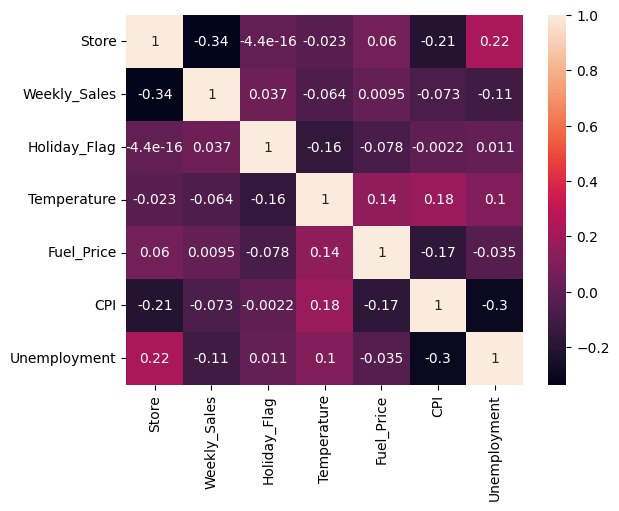

In [132]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

<Axes: xlabel='Date'>

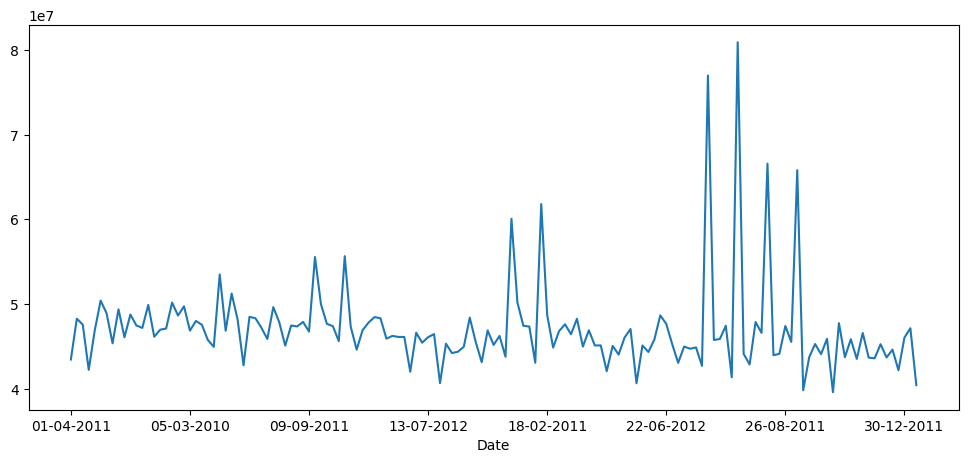

In [133]:
# Sales trend
df.groupby('Date')['Weekly_Sales'].sum().plot(figsize=(12,5))

<Axes: xlabel='Holiday_Flag', ylabel='Weekly_Sales'>

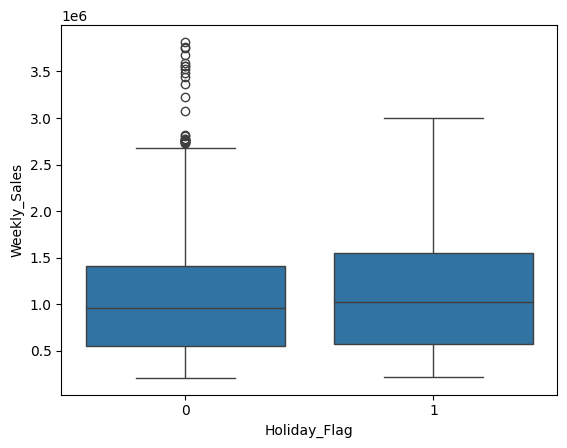

In [134]:
# Holiday vs Non-Holiday
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)

<Axes: xlabel='Store'>

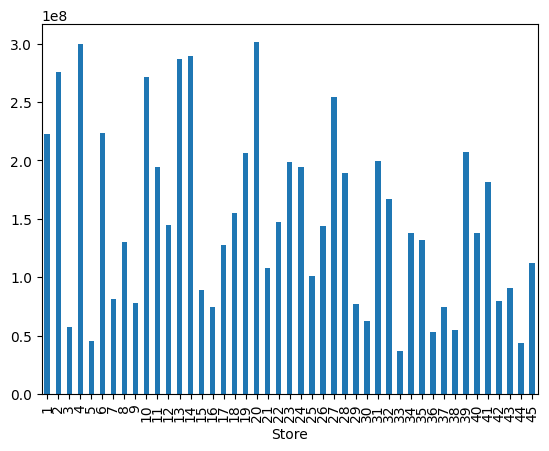

In [135]:
# Store-wise sales
df.groupby('Store')['Weekly_Sales'].sum().plot(kind='bar')

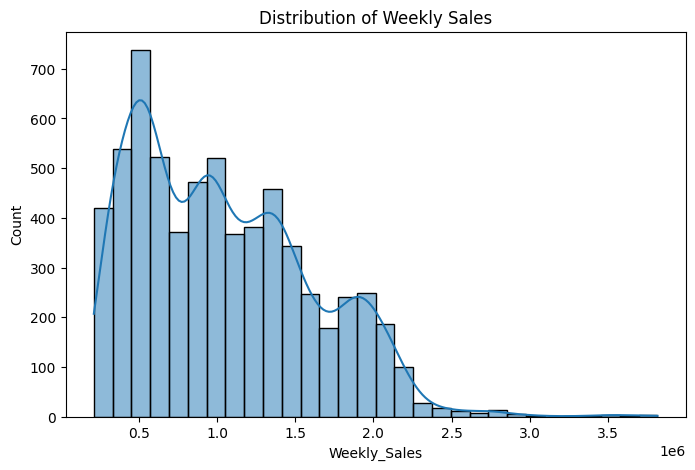

In [136]:
plt.figure(figsize=(8,5))
sns.histplot(df['Weekly_Sales'],
             bins=30,
             kde=True)

plt.title("Distribution of Weekly Sales")
plt.show()

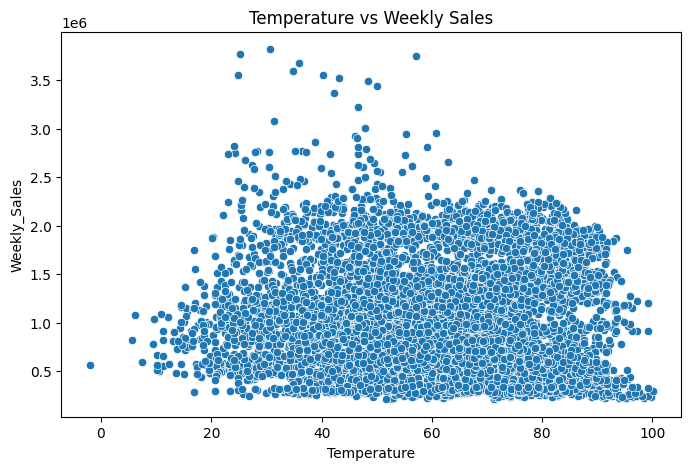

In [137]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Temperature',
    y='Weekly_Sales',
    data=df
)

plt.title("Temperature vs Weekly Sales")
plt.show()

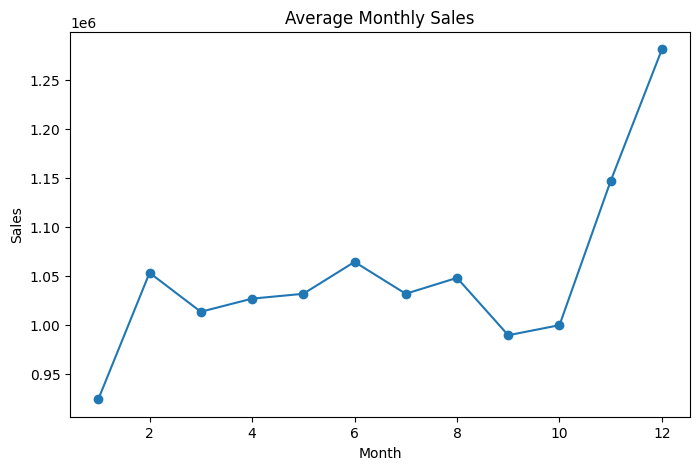

In [138]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(8,5))
monthly_sales.plot(marker='o')

plt.title("Average Monthly Sales")
plt.ylabel("Sales")
plt.show()

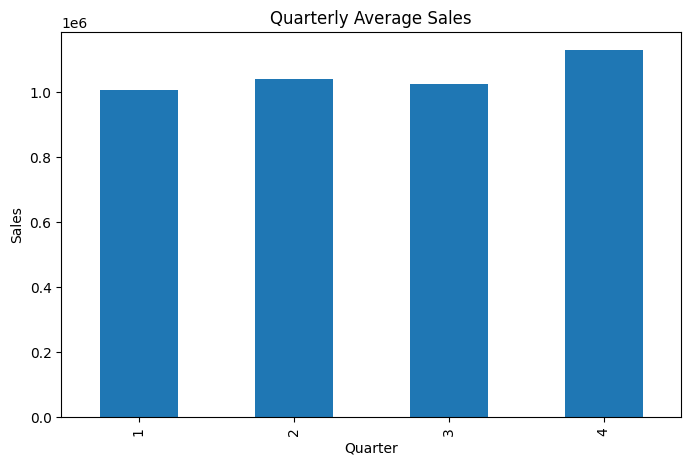

In [139]:
df['Quarter'] = df['Date'].dt.quarter
quarterly_sales = df.groupby('Quarter')['Weekly_Sales'].mean()

plt.figure(figsize=(8,5))
quarterly_sales.plot(kind='bar')

plt.title("Quarterly Average Sales")
plt.ylabel("Sales")
plt.show()

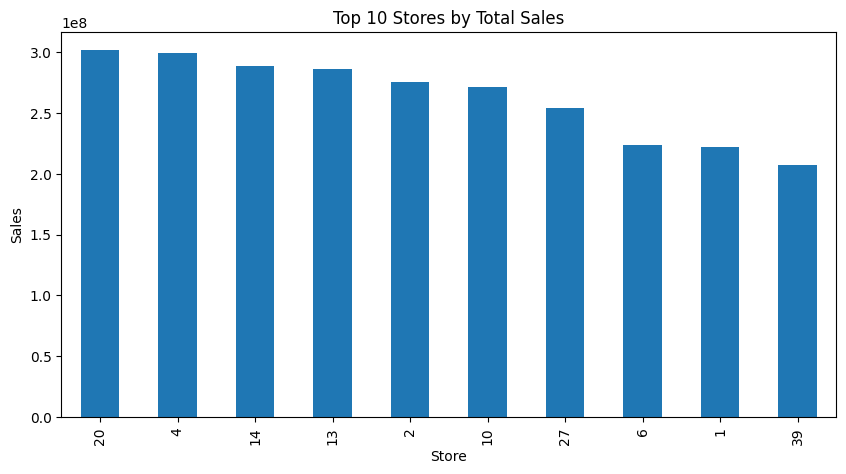

In [140]:
top10 = (df.groupby('Store')['Weekly_Sales']
           .sum()
           .sort_values(ascending=False)
           .head(10))

plt.figure(figsize=(10,5))
top10.plot(kind='bar')

plt.title("Top 10 Stores by Total Sales")
plt.ylabel("Sales")
plt.show()

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Extract numerical features from 'Date'
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Features and Target
X = df.drop(["Weekly_Sales", "Date"], axis=1) # Drop original 'Date' column
y = df["Weekly_Sales"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
rf = RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1)

rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 57538.00
RMSE : 114064.01
R²   : 0.9596


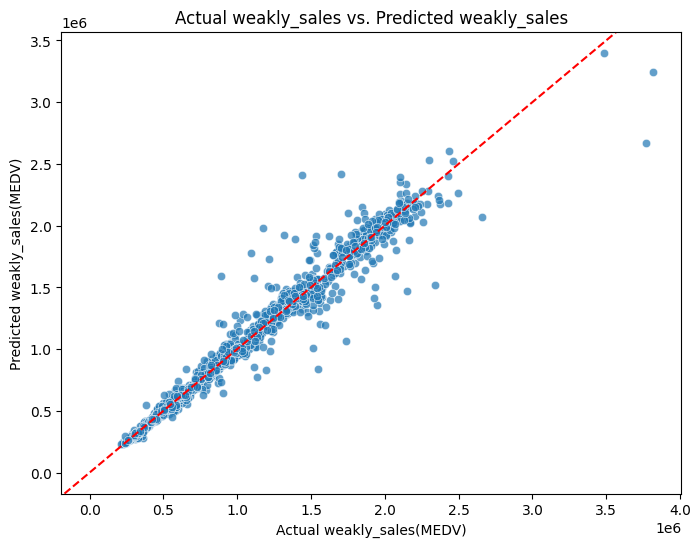

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual weakly_sales(MEDV)")
plt.ylabel("Predicted weakly_sales(MEDV)")
plt.title("Actual weakly_sales vs. Predicted weakly_sales")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [143]:
from scipy.stats import skew
skewness = df.skew(numeric_only=True)

num_cols=len(df.columns)

In [144]:
df[highly_skewed] = df[highly_skewed].apply(lambda x: np.log1p(x))

from sklearn.preprocessing import PowerTransformer

# Identify negatively skewed features (excluding the target 'Weekly_Sales')
negatively_skewed_features_list = [col for col in negatively_skewed if col != 'Weekly_Sales']
pt_features = PowerTransformer(method="yeo-johnson")
df[negatively_skewed_features_list] = pt_features.fit_transform(df[negatively_skewed_features_list])

# Identify and transform the negatively skewed target 'Weekly_Sales' separately
# Based on the kernel state, 'Weekly_Sales' is indeed in negatively_skewed.
pt_target = PowerTransformer(method="yeo-johnson")
df['Weekly_Sales'] = pt_target.fit_transform(df[['Weekly_Sales']])

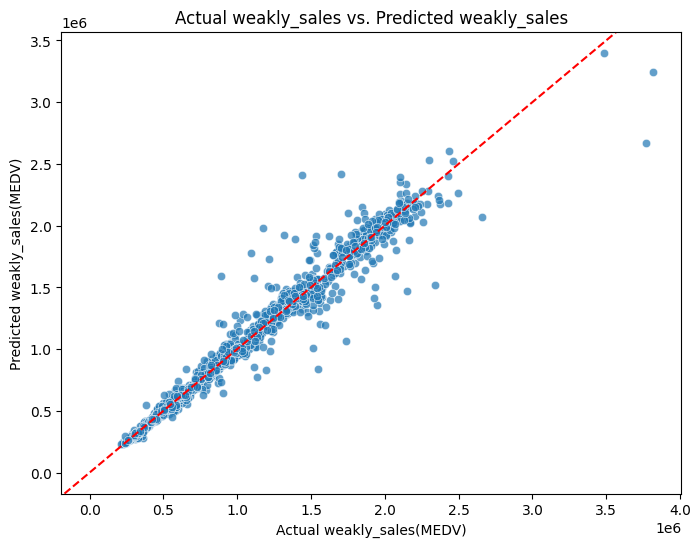

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual weakly_sales(MEDV)")
plt.ylabel("Predicted weakly_sales(MEDV)")
plt.title("Actual weakly_sales vs. Predicted weakly_sales")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [150]:
import pandas as pd
import numpy as np

new_data = pd.DataFrame({
    'Store': [1],
    'Date': ['2010-02-05'], # Add a Date column (example date)
    'Holiday_Flag': [0],
    'Temperature': [46.5],
    'Fuel_Price': [2.625],
    'CPI': [211.3501429],
    'Unemployment': [8.106]
})

# Convert Date to datetime and extract Year, Month, Day, Quarter
new_data['Date'] = pd.to_datetime(new_data['Date'])
new_data['Year'] = new_data['Date'].dt.year
new_data['Month'] = new_data['Date'].dt.month
new_data['Day'] = new_data['Date'].dt.day
new_data['Quarter'] = new_data['Date'].dt.quarter # Add Quarter feature

# Remove log1p transformations for Holiday_Flag and Unemployment
# The rf model was trained on untransformed features (verified from X_train kernel state).
# new_data['Holiday_Flag'] = np.log1p(new_data['Holiday_Flag'])
# new_data['Unemployment'] = np.log1p(new_data['Unemployment'])

# Drop the original 'Date' column, similar to how X was prepared for training
new_data = new_data.drop(columns=['Date'])

# Reorder new_data columns to match the training data (X_train) column order
# X_train.columns was ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Quarter', 'Year', 'Day']
new_data = new_data[X_train.columns]

# Use the Random Forest Regressor model for prediction as it performed much better
prediction = rf.predict(new_data)

print(f"Predicted Weekly Sales: {prediction[0]:.2f}")

Predicted Weekly Sales: 1561974.51
